In [ ]:
import numpy as np
import scanpy as sc

sc.settings.verbosity = 3

/root/data1/GY/Mambaforge/envs/openbiomed/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# cell_iname colors
cell_colors = ['#023fa5',
 '#7d87b9',
 '#bec1d4',
 '#d6bcc0',
 '#bb7784',
 '#8e063b',
 '#4a6fe3',
 '#8595e1',
 '#b5bbe3',
 '#e6afb9',
 '#e07b91',
 '#d33f6a',
 '#11c638',
 '#8dd593',
 '#c6dec7',
 '#ead3c6',
 '#f0b98d',
 '#ef9708',
 '#0fcfc0',
 '#9cded6',
 '#d5eae7',
 '#f3e1eb',
 '#f6c4e1']

# tissue_colors
tissue_colors = ['#1f77b4',
 '#ff7f0e',
 '#279e68',
 '#d62728',
 '#aa40fc',
 '#8c564b',
 '#e377c2',
 '#b5bd61',
 '#17becf',
 '#aec7e8',
 '#ffbb78',
 '#98df8a',
 '#ff9896',
 '#c5b0d5']

# Load embedding

In [3]:
adata =  sc.read_h5ad('../../processed_data/l1000_sdst_78453_5.h5ad')
tissue_idx_dict = np.load('/root/data1/GY/gy/drugPert/data/l1000_info_processed/l1000_tissue2idx_21.npy', allow_pickle=True).item()
idx2tissue = {v:k for k,v in tissue_idx_dict.items()}
adata.obs['tissue'] = adata.obs.tissue_idx.map(idx2tissue)
adata

AnnData object with n_obs × n_vars = 78453 × 978
    obs: 'sample_id', 'bead_batch', 'nearest_dose', 'pert_dose', 'pert_dose_unit', 'pert_idose', 'pert_time', 'pert_itime', 'pert_time_unit', 'cell_mfc_name', 'pert_mfc_id', 'det_plate', 'det_well', 'rna_plate', 'rna_well', 'count_mean', 'count_cv', 'qc_f_logp', 'qc_iqr', 'qc_slope', 'pert_id', 'pert_type', 'cell_iname', 'qc_pass', 'dyn_range', 'inv_level_10', 'build_name', 'failure_mode', 'project_code', 'cmap_name', 'n_replicates', 'pert_idx', 'cell_idx', 'tissue_idx', 'cell_pert_dose_time', 'split_1', 'split_2', 'split_3', 'split_4', 'split_5', 'split_cold_drug_1', 'split_cold_drug_2', 'split_cold_drug_3', 'split_cold_drug_4', 'split_cold_drug_5', 'split_cold_cell_1', 'split_cold_cell_2', 'split_cold_cell_3', 'split_cold_cell_4', 'split_cold_cell_5', 'split_cold_cell_1_one_shot', 'split_cold_cell_1_0.1_shot', 'split_cold_cell_1_0.3_shot', 'split_cold_cell_1_0.5_shot', 'split_cold_cell_1_0.8_shot', 'split_cold_cell_2_one_shot', 'split_

In [ ]:
file_path = 'l1000_sdst_cls_embed'
fold = 'split_1'
all_cls_embed = np.load(file_path + f'/l1000_sdst_{fold}_test_samples_cls_embed.npy', allow_pickle=True)
all_cls_embed.shape

(78453, 2, 256)

In [ ]:
adata.obsm['trt_cls_embed'] = all_cls_embed[:,0,:]
adata.obsm['ctl_cls_embed'] = all_cls_embed[:,1,:]
adata

AnnData object with n_obs × n_vars = 78453 × 978
    obs: 'sample_id', 'bead_batch', 'nearest_dose', 'pert_dose', 'pert_dose_unit', 'pert_idose', 'pert_time', 'pert_itime', 'pert_time_unit', 'cell_mfc_name', 'pert_mfc_id', 'det_plate', 'det_well', 'rna_plate', 'rna_well', 'count_mean', 'count_cv', 'qc_f_logp', 'qc_iqr', 'qc_slope', 'pert_id', 'pert_type', 'cell_iname', 'qc_pass', 'dyn_range', 'inv_level_10', 'build_name', 'failure_mode', 'project_code', 'cmap_name', 'n_replicates', 'pert_idx', 'cell_idx', 'tissue_idx', 'cell_pert_dose_time', 'split_1', 'split_2', 'split_3', 'split_4', 'split_5', 'split_cold_drug_1', 'split_cold_drug_2', 'split_cold_drug_3', 'split_cold_drug_4', 'split_cold_drug_5', 'split_cold_cell_1', 'split_cold_cell_2', 'split_cold_cell_3', 'split_cold_cell_4', 'split_cold_cell_5', 'split_cold_cell_1_one_shot', 'split_cold_cell_1_0.1_shot', 'split_cold_cell_1_0.3_shot', 'split_cold_cell_1_0.5_shot', 'split_cold_cell_1_0.8_shot', 'split_cold_cell_2_one_shot', 'split_

# Data filtering and get plotting data

In [9]:
np.random.seed(1024)

In [10]:
adata_filter = adata[adata.obs[fold] == 'test']

In [11]:
adata_filter.obs.tissue.value_counts()

tissue
prostate                              2552
lung                                  2453
breast                                2219
unknown                               1432
skin                                  1223
kidney                                1007
large_intestine                        722
central_nervous_system                 668
soft_tissue                            662
haematopoietic_and_lymphoid_tissue     572
endometrium                            504
liver                                  366
cervix                                 282
urinary_tract                          272
pancreas                               239
ovary                                  226
bone                                   183
stomach                                 54
autonomic_ganglia                       20
upper_aerodigestive_tract               18
placenta                                16
Name: count, dtype: int64

In [ ]:
tissue_remain_ls = list(adata_filter.obs.tissue.values)
tissue_remain_ls.remove('unknown')
adata_filter = adata_filter[adata_filter.obs.tissue.isin(tissue_remain_ls)]

In [ ]:
cell_id_statics = dict(adata_filter.obs.cell_iname.value_counts())
cell_id_statics
cell_id_statics_filter = {k:v for k,v in cell_id_statics.items() if v>130}

cell_id_filter = list(cell_id_statics_filter.keys())
print(len(cell_id_filter))
adata_filter = adata_filter[adata_filter.obs['cell_iname'].isin(cell_id_filter)]

23

In [16]:
infer_adata = adata_filter
infer_adata.obs.tissue_idx = infer_adata.obs.tissue_idx.astype('category')
infer_adata = infer_adata[infer_adata.obs.tissue_idx.argsort()]
cell_iname = infer_adata.obs.cell_iname.values
infer_adata

/root/data1/GY/Mambaforge/envs/openbiomed/lib/python3.9/site-packages/pandas/core/generic.py:6348: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  self[name] = value


View of AnnData object with n_obs × n_vars = 11069 × 978
    obs: 'sample_id', 'bead_batch', 'nearest_dose', 'pert_dose', 'pert_dose_unit', 'pert_idose', 'pert_time', 'pert_itime', 'pert_time_unit', 'cell_mfc_name', 'pert_mfc_id', 'det_plate', 'det_well', 'rna_plate', 'rna_well', 'count_mean', 'count_cv', 'qc_f_logp', 'qc_iqr', 'qc_slope', 'pert_id', 'pert_type', 'cell_iname', 'qc_pass', 'dyn_range', 'inv_level_10', 'build_name', 'failure_mode', 'project_code', 'cmap_name', 'n_replicates', 'pert_idx', 'cell_idx', 'tissue_idx', 'cell_pert_dose_time', 'split_1', 'split_2', 'split_3', 'split_4', 'split_5', 'split_cold_drug_1', 'split_cold_drug_2', 'split_cold_drug_3', 'split_cold_drug_4', 'split_cold_drug_5', 'split_cold_cell_1', 'split_cold_cell_2', 'split_cold_cell_3', 'split_cold_cell_4', 'split_cold_cell_5', 'split_cold_cell_1_one_shot', 'split_cold_cell_1_0.1_shot', 'split_cold_cell_1_0.3_shot', 'split_cold_cell_1_0.5_shot', 'split_cold_cell_1_0.8_shot', 'split_cold_cell_2_one_shot',

In [17]:
trt_cls_adata = sc.AnnData(X=infer_adata.obsm['trt_cls_embed'], obs=infer_adata.obs)

# Plot raw_trt

computing PCA
    with n_comps=40
    finished (0:00:01)
computing neighbors


/root/data1/GY/Mambaforge/envs/openbiomed/lib/python3.9/site-packages/scanpy/preprocessing/_pca.py:229: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm['X_pca'] = X_pca


    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:30)
computing UMAP


/root/data1/GY/Mambaforge/envs/openbiomed/lib/python3.9/site-packages/sklearn/manifold/_spectral_embedding.py:285: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:07)


/root/data1/GY/Mambaforge/envs/openbiomed/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/root/data1/GY/Mambaforge/envs/openbiomed/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/root/data1/GY/Mambaforge/envs/openbiomed/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.

[<Axes: title={'center': 'cell_iname'}, xlabel='UMAP1', ylabel='UMAP2'>,
 <Axes: title={'center': 'tissue'}, xlabel='UMAP1', ylabel='UMAP2'>]

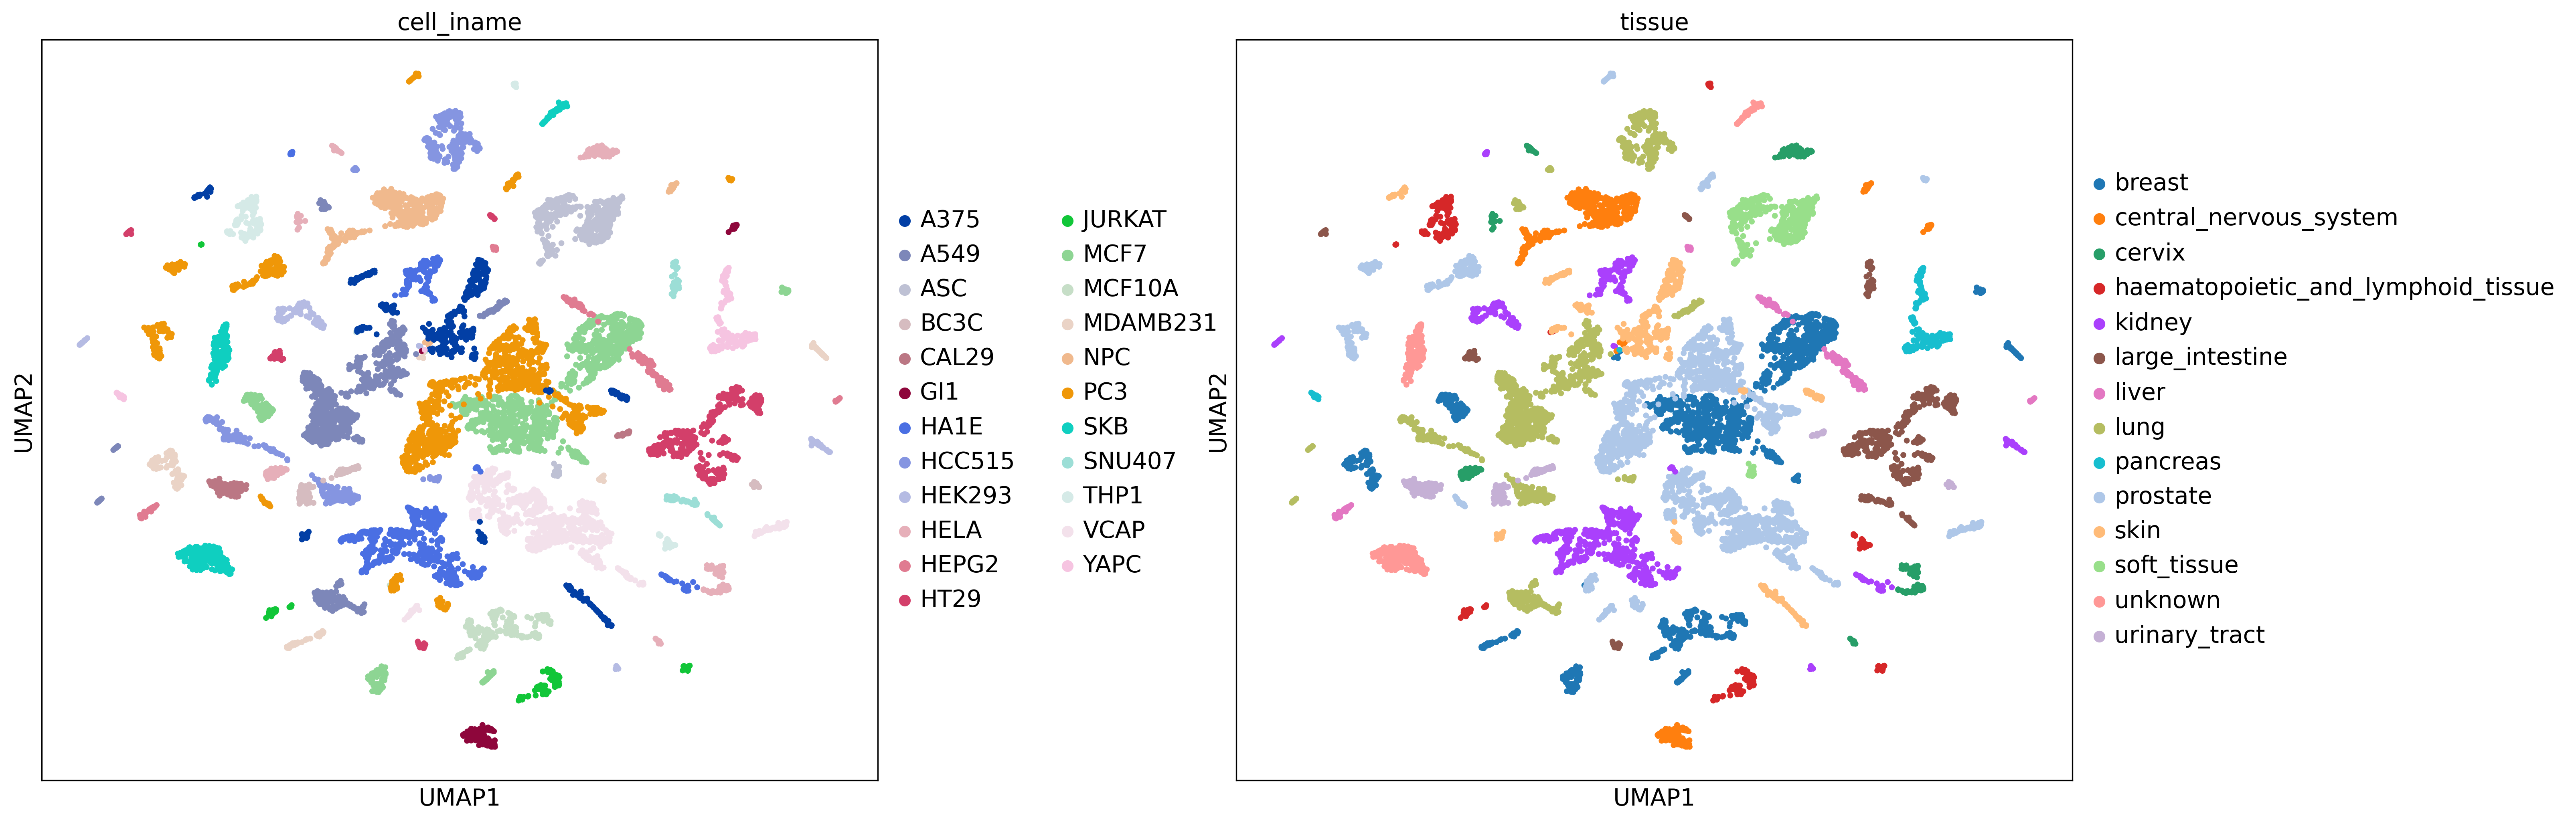

In [ ]:
plot_adata = infer_adata
sc.set_figure_params(figsize=(8.5, 8), dpi=150)

sc.pp.pca(plot_adata, n_comps=40)
sc.pp.neighbors(plot_adata, n_neighbors=15, use_rep='X_pca')

sc.tl.umap(plot_adata)
sc.pl.umap(plot_adata, color=['cell_iname', 'tissue'], wspace=0.3, size=50, legend_fontsize=14, show=False)

# plt.savefig('figs/l1000_sdst_cell_embed_raw.svg',format='svg',dpi=300, bbox_inches='tight')

# Plot cls_trt

computing PCA
    with n_comps=40
    finished (0:00:00)
computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:03)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:07)


/root/data1/GY/Mambaforge/envs/openbiomed/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/root/data1/GY/Mambaforge/envs/openbiomed/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/root/data1/GY/Mambaforge/envs/openbiomed/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.

[<Axes: title={'center': 'cell_iname'}, xlabel='UMAP1', ylabel='UMAP2'>,
 <Axes: title={'center': 'tissue'}, xlabel='UMAP1', ylabel='UMAP2'>]

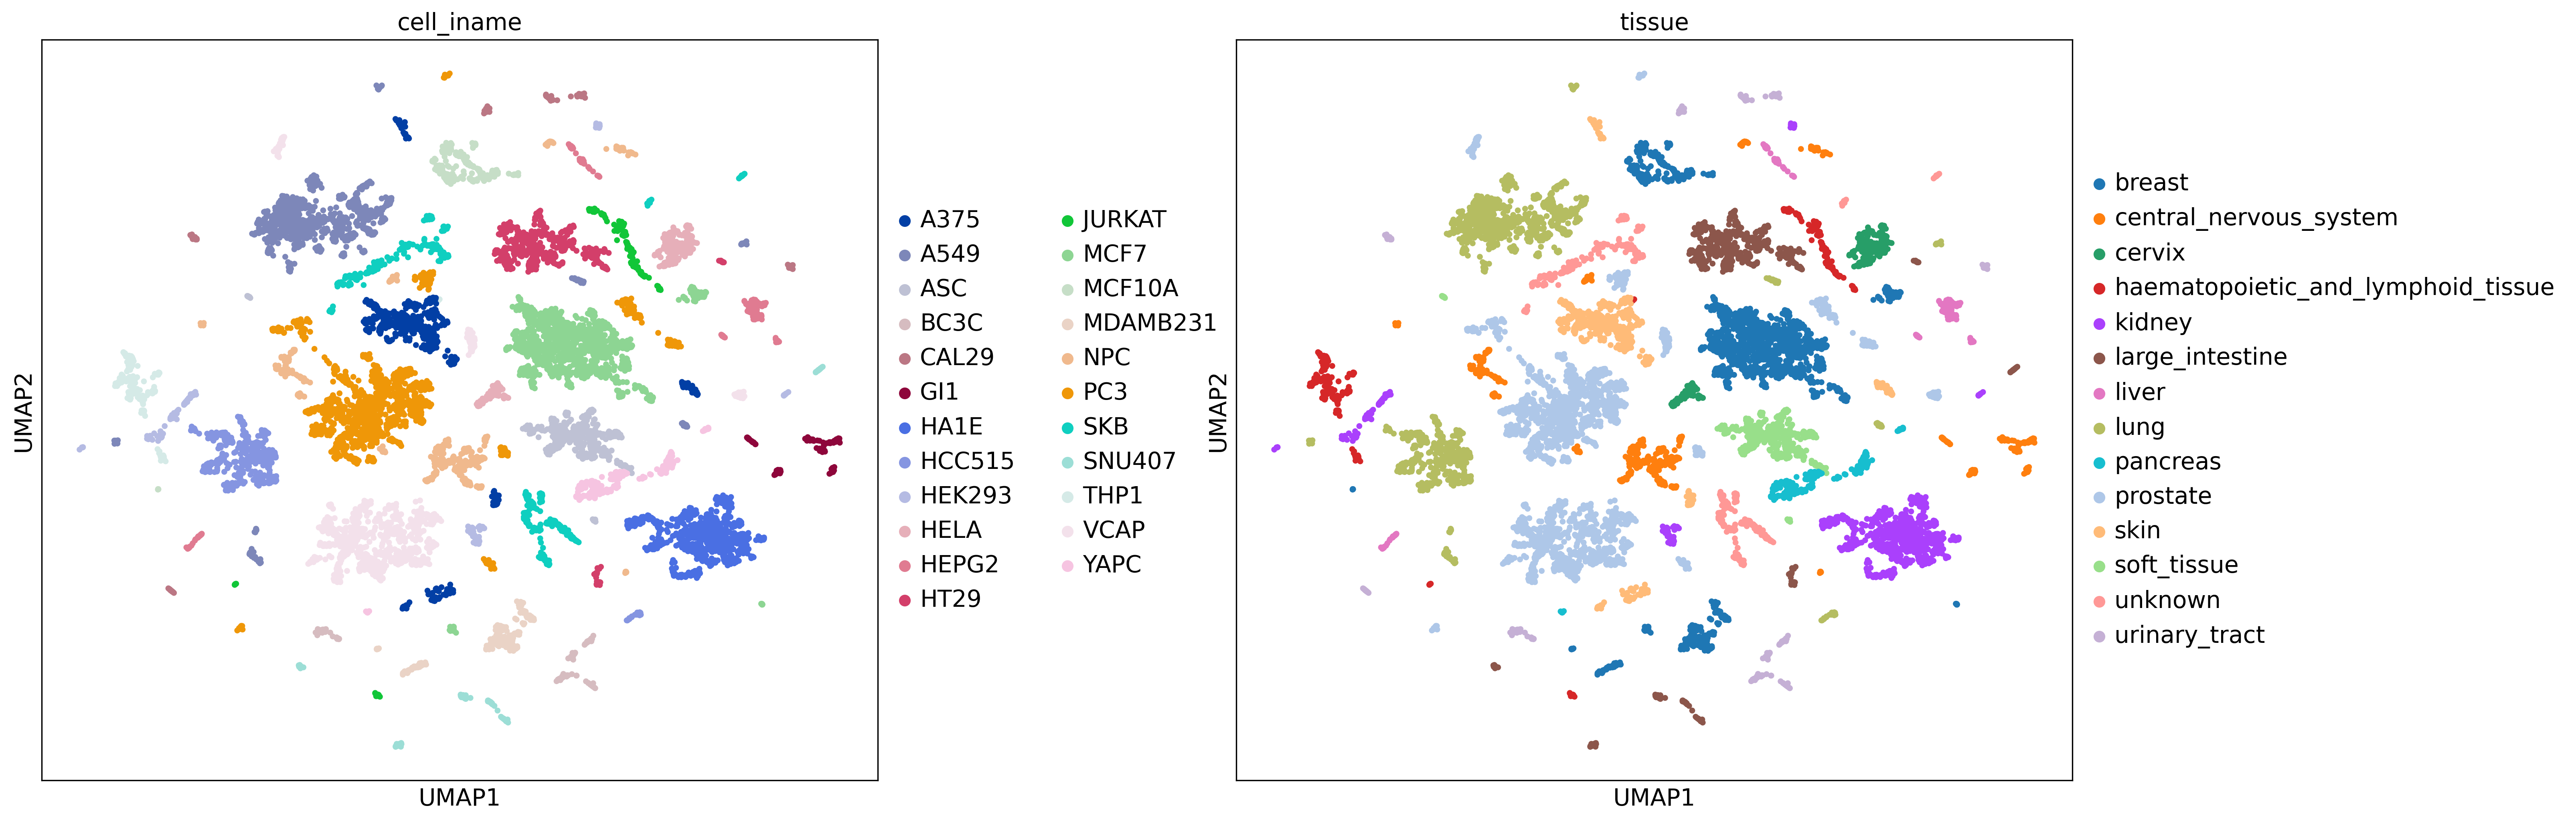

In [ ]:
plot_adata = trt_cls_adata
sc.set_figure_params(figsize=(8.5, 8), dpi=150)

sc.pp.pca(plot_adata, n_comps=40)
sc.pp.neighbors(plot_adata, n_neighbors=15, use_rep='X_pca')

sc.tl.umap(plot_adata)
sc.pl.umap(plot_adata, color=['cell_iname', 'tissue'], wspace=0.3, size=50, legend_fontsize=14, show=False)

# plt.savefig('figs/l1000_sdst_cell_embed_xpert.svg',format='svg',dpi=300, bbox_inches='tight')